In [1]:
import matplotlib.pyplot as plt
import numpy as np
#from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
#import datetime
#from xgrads import CtlDescriptor, open_CtlDataset, open_mfdataset
from shapely import wkt, plotting, Point, buffer, geometry
import netCDF4
import os
import cmweather
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 28

from scipy.fft import ifft, fft, fftfreq

PLUG THIS INTO A POISSON SOLVE (POISSON PY) AND SEE WHAT HAPPENS
TRY NEUMANN AND DIRELECHT BOUNDARY CONDS

Direchelet BCs -- constant at the ground (0, should have no vort at surface)

turns out we don't actually need a poisson solver -- just need to use Direchelt BC's to find the coeffs for the equation

In [14]:
x = np.linspace(0, 2, 1000)
##Default zeta curvess
zeta_default = -((x-1)**2) + 1
zeta_big = 1.2 * zeta_default
zeta_shift = np.sin(x - 0.4*np.sin(x))

#P'd Curves
pd_prime = (x**6)/30 -(x**5)/5 + (x**4)/3 -0.533333*x
pd_big = 0.048*(x**6) - 0.288*(x**5) + 0.48*(x**4) - 0.768*x

pd_shift = 0.26*(x**2) + 0.25*(np.cos(x)**2) - 0.2*np.cos(x) + \
0.022222*np.cos(3*x) + 0.00125*np.cos(4*x) + (0.7529044*x) -.27347

#ACCD Curves
accd_default = np.gradient(pd_prime)
accd_big = np.gradient(pd_big)
accd_shift = np.gradient(pd_shift)

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2626854/3328377247.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('Vorticity ($\mathrm{s^{-1}}$)')
/tmp/ipykernel_2626854/3328377247.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('a) Vorticity ($\mathbf{\zeta}$)', weight = 'bold')


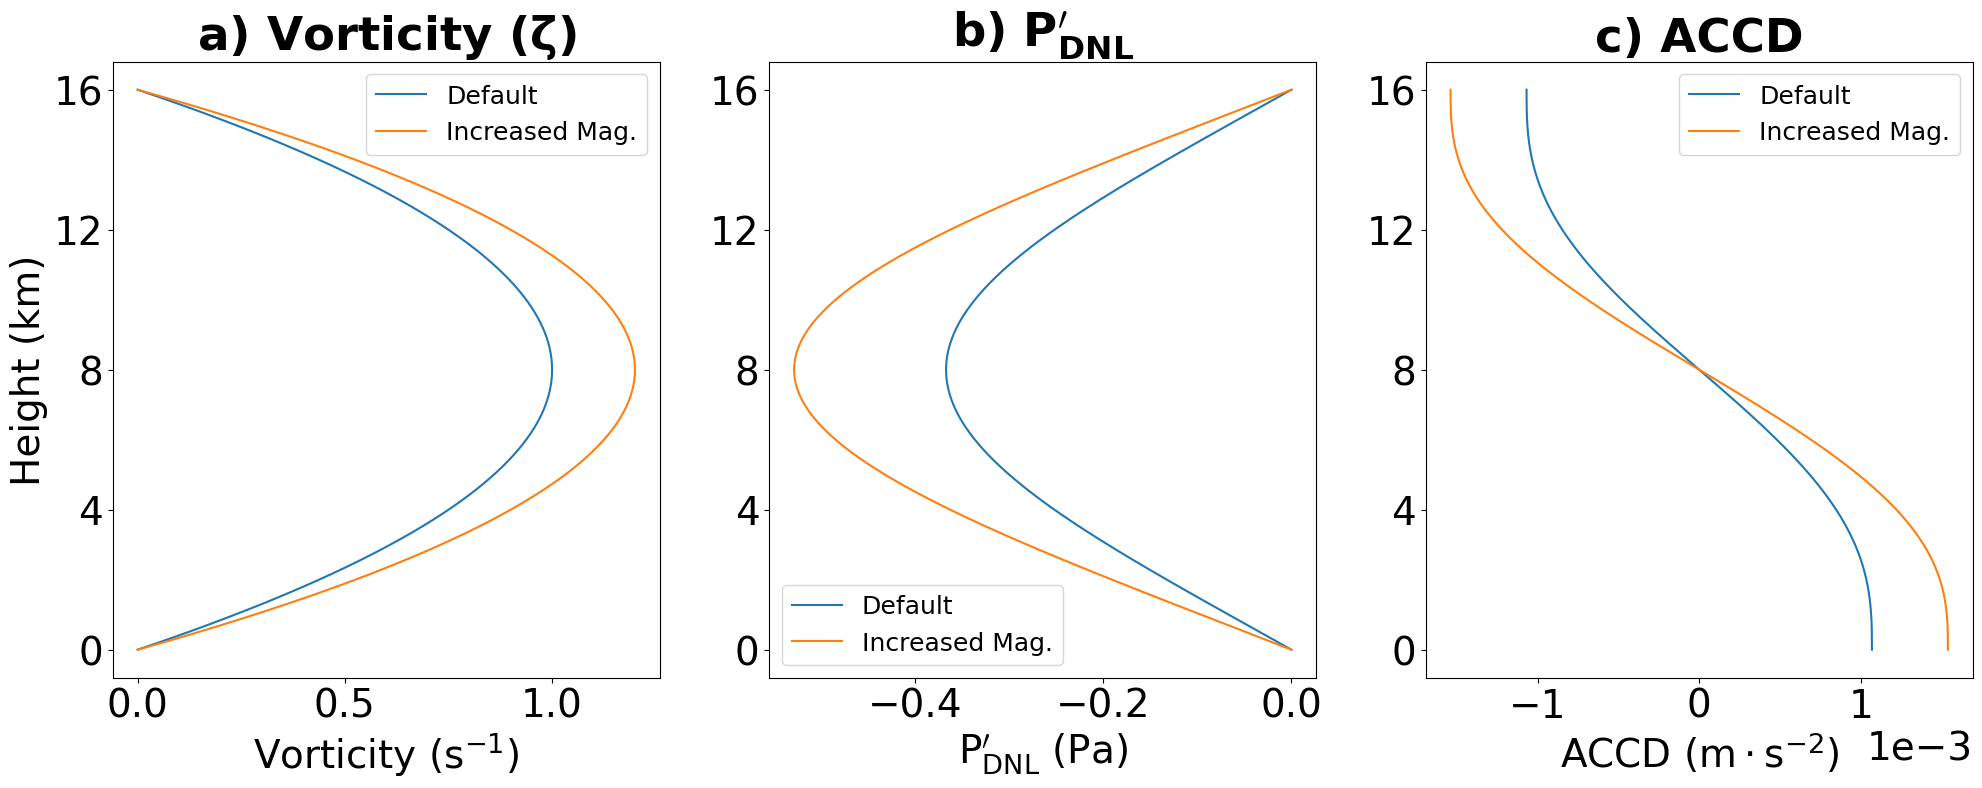

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 8))
ax1.plot(zeta_default, x, label = r'Default')
ax1.plot(zeta_big, x, label = r'Increased Mag.')
tick_labs = [0, 4, 8, 12, 16]
og_ticks = [0, 0.5, 1, 1.5, 2]
ax1.set_yticks(og_ticks, labels = tick_labs)
ax2.plot(pd_prime, x, label = r'Default')
ax2.plot(pd_big, x, label = r'Increased Mag.')
#ax2.plot(pd_shift, x, label = r'Shifted $P^{\prime}_{d}$')
ax1.legend(loc = 'best', fontsize = 18)
ax2.legend(loc = 'lower left', fontsize = 18)
ax2.set_yticks(og_ticks, tick_labs)
ax1.set_ylabel('Height (km)')
ax1.set_xlabel('Vorticity ($\mathrm{s^{-1}}$)')
ax2.set_xlabel(r'$\mathrm{P^{\prime}_{DNL}}$ (Pa)')
ax1.set_title('a) Vorticity ($\mathbf{\zeta}$)', weight = 'bold')
ax2.set_title(r'b) $\mathbf{P^{\prime}_{DNL}}$', weight = 'bold')
ax3.plot(accd_default*-1, x, label = 'Default')
ax3.plot(accd_big*-1, x, label = 'Increased Mag.')
ax3.set_yticks(og_ticks, tick_labs)
#ax3.plot(accd_default*-1, x, label = 'Shifted ACCD')
ax3.set_xlabel(r'ACCD ($\mathrm{m\cdot s^{-2}}$)')
ax3.ticklabel_format(axis='x', style = 'sci', scilimits=(0, 0))
ax3.set_title('c) ACCD', weight = 'bold')
ax3.legend(loc = 'best', fontsize = 18)

## Updated p'b method!

In [50]:
#Following the warm bubble method from CM1 (let's only do it in 2d though, not 3d)
ric = 200
height_bub = 100
horiz_rad_narrow = 75
horiz_rad_wide = 150
vert_rad = 50
pt_perturb = 1

x_grid = 400
z_grid = 200
narrow_array = np.zeros((x_grid,  z_grid))
wide_array =  np.zeros((x_grid,  z_grid))

for x in np.arange(0, x_grid):
    for z in np.arange(0, z_grid):
        current_val = np.sqrt(
            ((x - ric)/horiz_rad_narrow)**2 +
            ((z - height_bub)/ vert_rad)**2)
        if current_val < 1:
            narrow_array[x,z] = pt_perturb * (np.cos(0.5*np.pi*current_val)**2)
        else:
            narrow_array[x,z] = 0
        current_val_wide = np.sqrt(
            ((x - ric)/horiz_rad_wide)**2 +
            ((z - height_bub)/ vert_rad)**2)
        if current_val < 1:
            wide_array[x,z] = pt_perturb * (np.cos(0.5*np.pi*current_val_wide)**2)
        else:
            wide_array[x,z] = 0 
#Let's convert the theta plume into buoyancy
#Assuming a background theta of 0.1
#bt_theta = 
#narrow_array = 9.8 * ((narrow_array - bt_theta) / bt_theta)
filt_narrow = np.where(narrow_array > 0, narrow_array, np.nan)
#wide_array = 9.8 * ((wide_array - bt_theta) / bt_theta) 
filt_wide = np.where(wide_array > 0, wide_array, np.nan)

In [51]:
#Using the profiles we generated above -- let's calculate the Laplacian and the resultant accelerations!
from numpy.fft import fftn,ifftn

def inv_laplacian3d(field):
    """Thank you Daniel <3"""
    kx = 2*np.pi*fftfreq(field.shape[0], 1)
    kz = 2*np.pi*fftfreq(field.shape[1], 1)
    laplacian_fft = -(kx[:,np.newaxis]**2 + kz[np.newaxis,:]**2)
    laplacian_fft[0,0] = np.nan 
    inv_laplacian_fft = laplacian_fft**-1
    inv_laplacian_fft[0,0] = 0 # constant of integration
    return ifftn(inv_laplacian_fft*fftn(field))

pb_narrow = inv_laplacian3d(np.gradient(narrow_array,axis=1))
pb_narrow[0,:] = 0
pb_narrow[-1, :] = 0
accb_narrow = np.gradient(pb_narrow, axis = 1)
pb_wide = inv_laplacian3d(np.gradient(wide_array,axis=1)) 
pb_wide[0,:] = 0
pb_narrow[-1,:] = 0
accb_wide = np.gradient(pb_wide, axis = 0)


<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1530704/3800711343.py:23: SyntaxWarning: invalid escape sequence '\m'
  c1.set_label('Buoyancy ($\mathbf{m \cdot s^{-2}}$)', weight = 'bold')
/tmp/ipykernel_1530704/3800711343.py:25: SyntaxWarning: invalid escape sequence '\m'
  c2.set_label('$\mathbf{P^{\prime}_{b}}$ (Pa)', weight = 'bold')
/data/keeling/a/melinda3/miniconda3/envs/xgrads_env/lib/python3.13/site-packages/matplotlib/contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/data/keeling/a/melinda3/miniconda3/envs/xgrads_env/lib/python3.13/site-packages/matplotlib/contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/data/keeling/a/melinda3/miniconda3/envs/xgrads_

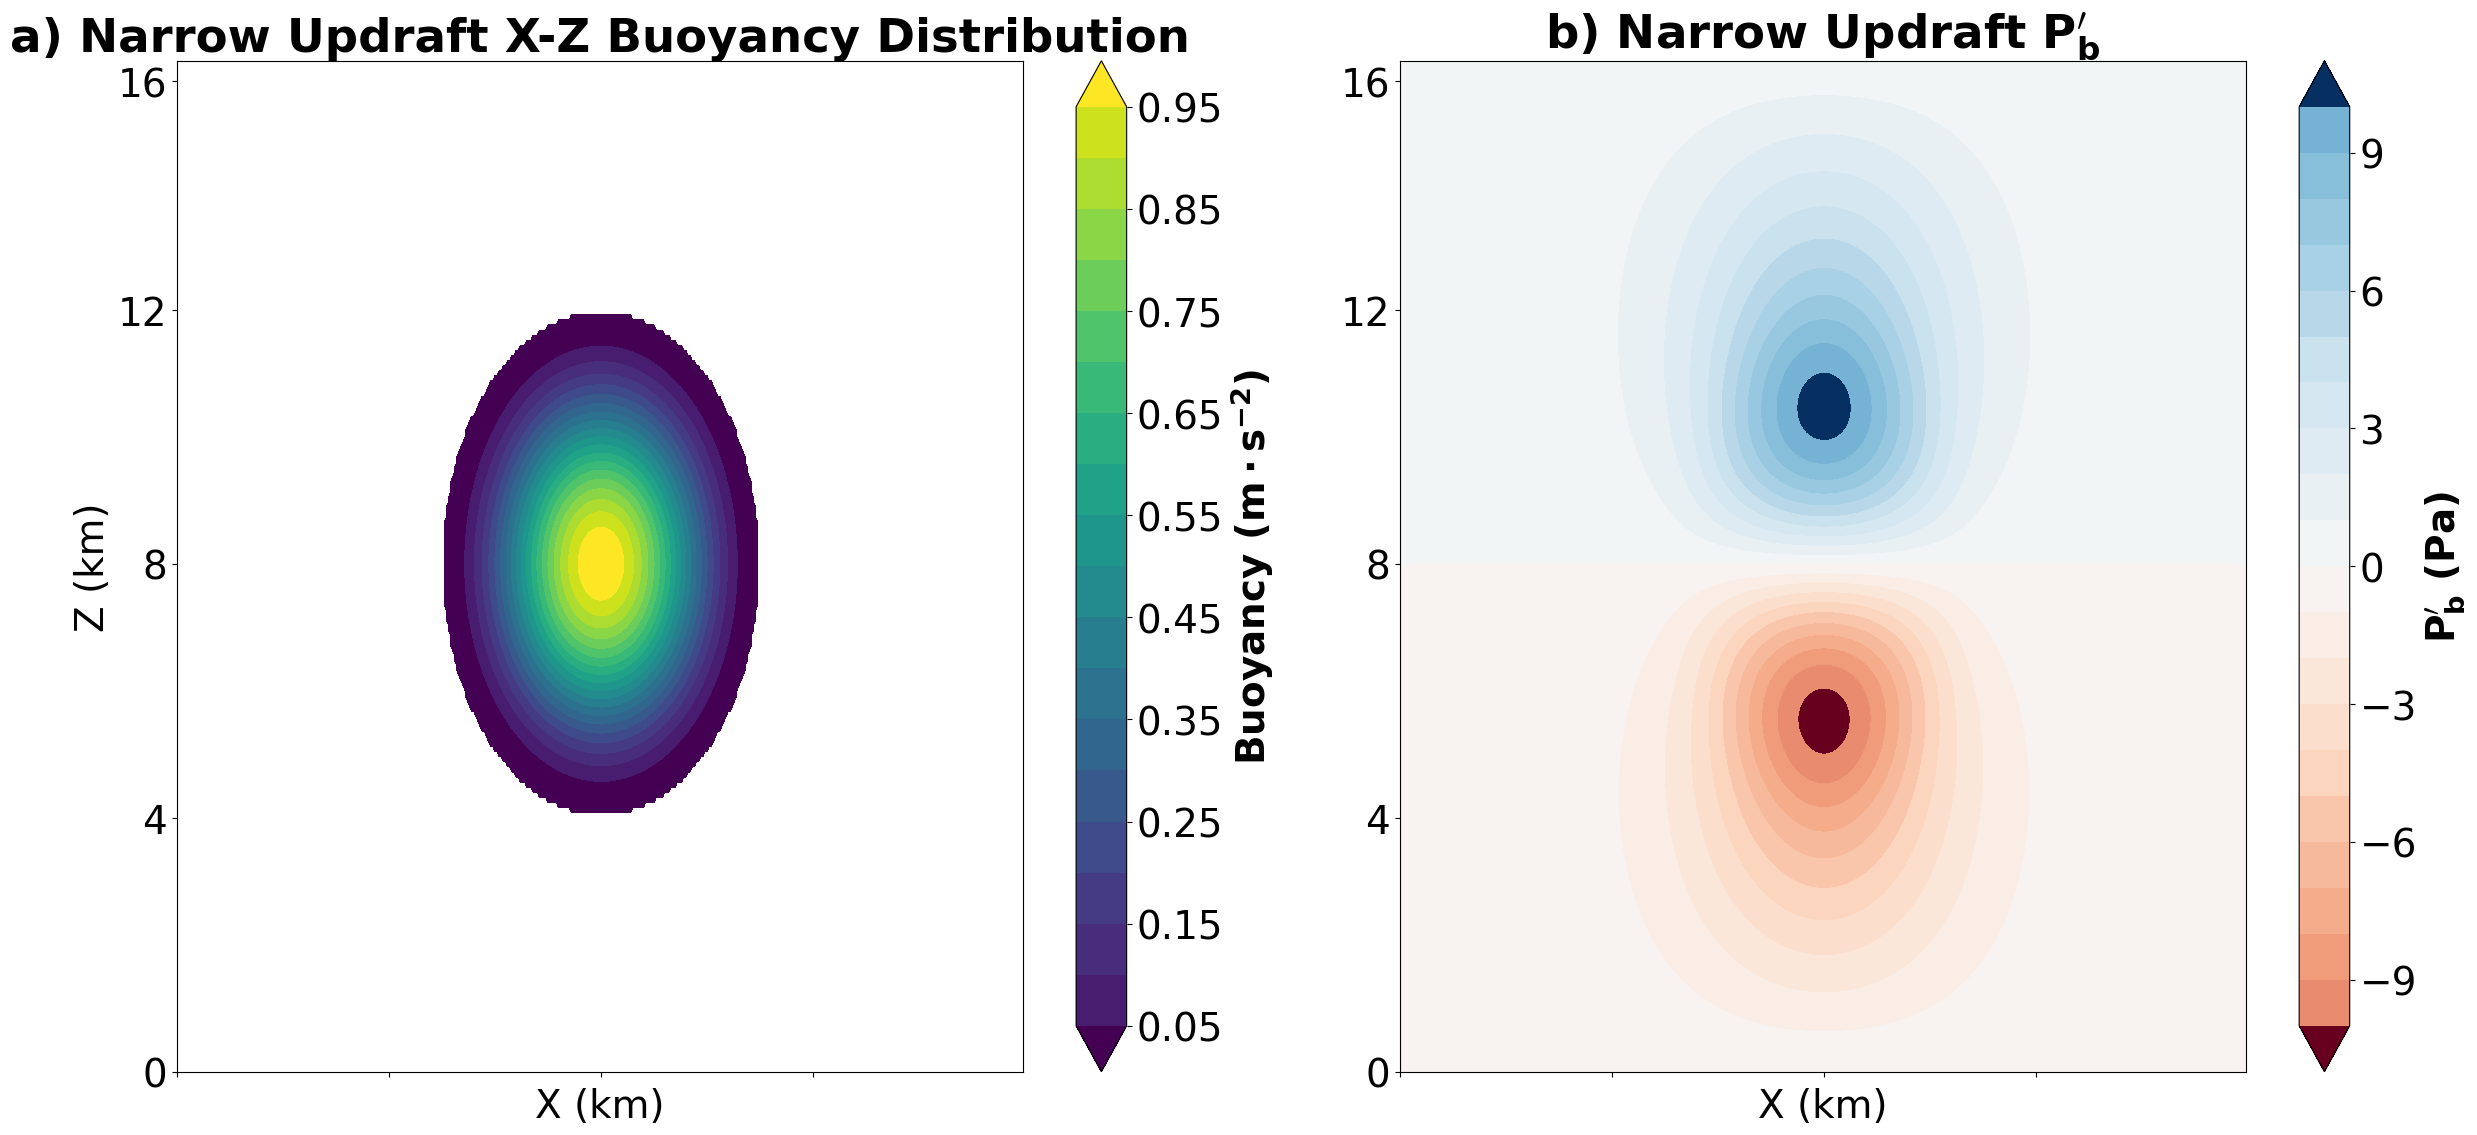

In [54]:
#Let's generate some pseudo buoyancy blobs
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (25, 12))
a1 = ax1.contourf(np.arange(x_grid), np.arange(z_grid), filt_narrow.T, cmap = 'viridis', vmin = 0, vmax = 1, extend = 'both', levels = 20)
tick_labs = [0, 4, 8, 12, 16]
og_ticks = [0, 50, 100, 150, 195]
ax1.set_xlabel('X (km)')
ax1.set_ylabel('Z (km)')
ax1.set_title('a) Narrow Updraft X-Z Buoyancy Distribution', weight = 'bold')
ax1.set_xticklabels([])
ax1.set_yticks(og_ticks, tick_labs)
ax2.set_xlabel('X (km)')
ax2.set_title(r'b) Narrow Updraft $\mathbf{P^{\prime}_{b}}$', weight = 'bold')
a2 = ax2.contourf(np.arange(x_grid), np.arange(z_grid), pb_narrow.T, cmap = 'RdBu', levels = 20, vmin = -20, vmax = 20, extend = 'both')
ax2.set_xticklabels([])
#a3 = ax3.contourf(np.arange(x_grid), np.arange(z_grid), accb_narrow.T*-1, cmap = 'PuOr', levels = 20, vmin = -0.5, vmax = 0.5, extend = 'both')
#ax3.set_xticklabels([])
#ax3.set_xlabel('X (km)')
#ax3.set_title(r'c) Narrow VBPGF', weight = 'bold')
ax1.set_yticks(og_ticks, tick_labs)
ax2.set_yticks(og_ticks, tick_labs)
#ax3.set_yticks(og_ticks, tick_labs)
c1 = plt.colorbar(a1, ax=ax1, label = 'Theta (K)', extend = 'both')
c1.set_label('Buoyancy ($\mathbf{m \cdot s^{-2}}$)', weight = 'bold')
c2 = plt.colorbar(a2, ax=ax2, extend = 'both')
c2.set_label('$\mathbf{P^{\prime}_{b}}$ (Pa)', weight = 'bold')
#c3 = plt.colorbar(a3, ax=ax3, extend = 'both')
#c3.set_label('VBPGF ($\mathbf{kg \cdot m  \cdot {s^{-2}}}$)', weight = 'bold')
plt.tight_layout()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1530704/340135585.py:16: SyntaxWarning: invalid escape sequence '\m'
  c1 = plt.colorbar(a1, ax=ax1, label = 'Buoyancy ($\mathbf{m \cdot s^{-2}}$)', extend = 'both')
/tmp/ipykernel_1530704/340135585.py:17: SyntaxWarning: invalid escape sequence '\m'
  c1.set_label('Buoyancy ($\mathbf{m \cdot s^{-2}}$)', weight = 'bold')
/tmp/ipykernel_1530704/340135585.py:19: SyntaxWarning: invalid escape sequence '\m'
  c2.set_label('$\mathbf{P^{\prime}_{b}}$ (Pa)', weight = 'bold')
/data/keeling/a/melinda3/miniconda3/envs/xgrads_env/lib/python3.13/site-packages/matplotlib/contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().a

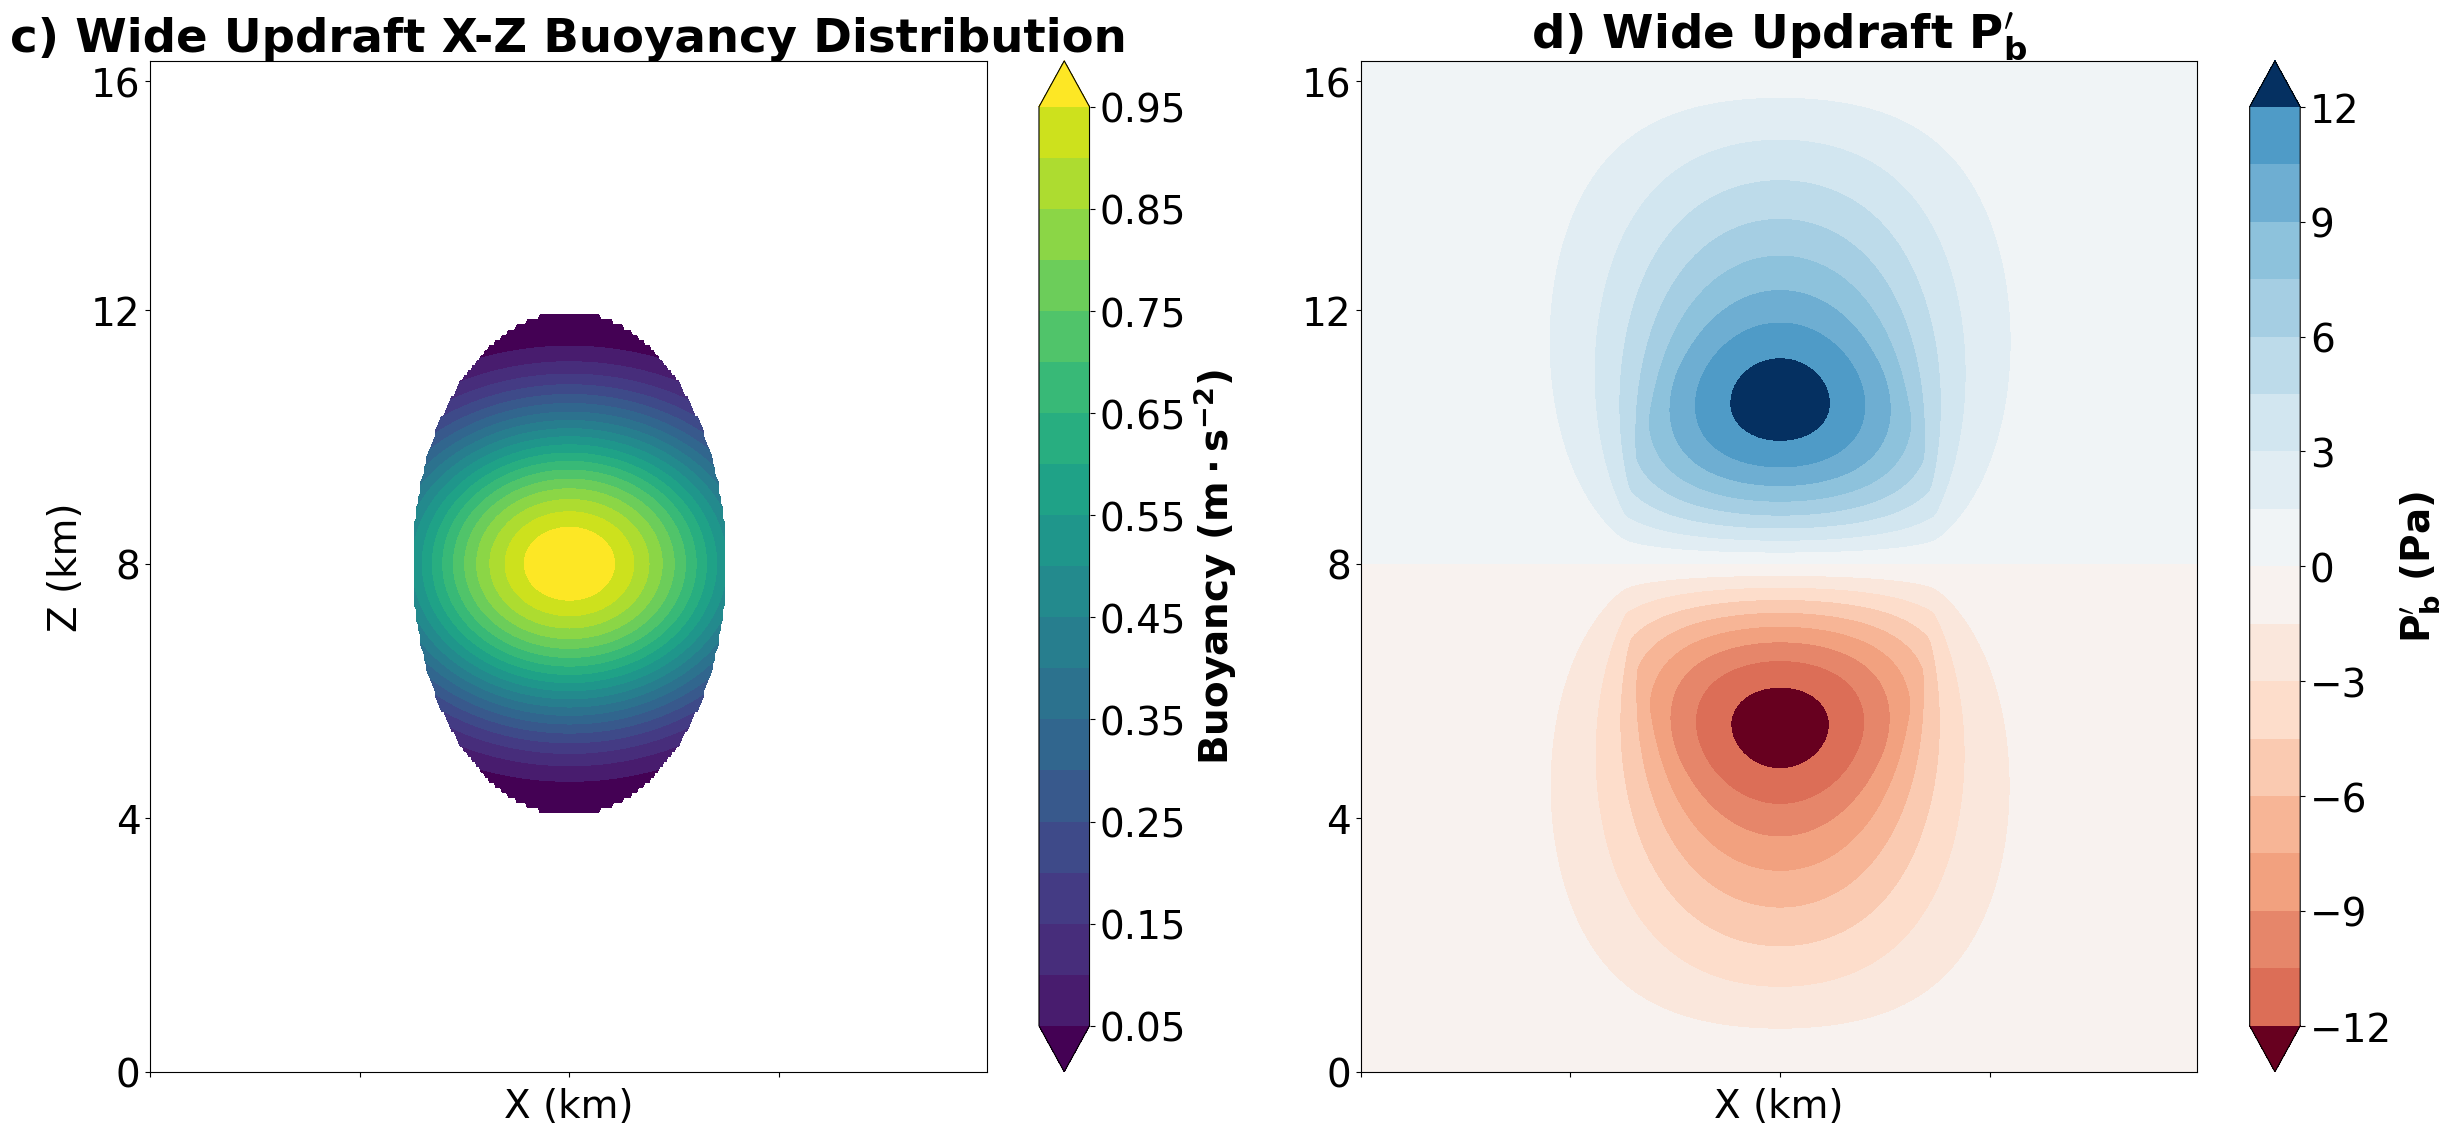

In [56]:
#Let's generate some pseudo buoyancy blobs
fig, (ax1, ax2 ) = plt.subplots(nrows = 1, ncols = 2, figsize = (25, 12))
a1 = ax1.contourf(np.arange(x_grid), np.arange(z_grid), filt_wide.T, cmap = 'viridis', vmin = 0, vmax = 1, extend = 'both', levels = 20)
tick_labs = [0, 4, 8, 12, 16]
og_ticks = [0, 50, 100, 150, 195]
ax1.set_xlabel('X (km)')
ax1.set_ylabel('Z (km)')
ax1.set_title('c) Wide Updraft X-Z Buoyancy Distribution', weight = 'bold')
ax1.set_xticklabels([])
ax2.set_xlabel('X (km)')
ax2.set_title(r'd) Wide Updraft $\mathbf{P^{\prime}_{b}}$', weight = 'bold')
a2 = ax2.contourf(np.arange(x_grid), np.arange(z_grid), pb_wide.T, cmap = 'RdBu', levels = 20,vmin = -20, vmax = 20, extend = 'both')
ax2.set_xticklabels([])
ax1.set_yticks(og_ticks, tick_labs)
ax2.set_yticks(og_ticks, tick_labs)
c1 = plt.colorbar(a1, ax=ax1, label = 'Buoyancy ($\mathbf{m \cdot s^{-2}}$)', extend = 'both')
c1.set_label('Buoyancy ($\mathbf{m \cdot s^{-2}}$)', weight = 'bold')
c2 = plt.colorbar(a2, ax=ax2, extend = 'both')
c2.set_label('$\mathbf{P^{\prime}_{b}}$ (Pa)', weight = 'bold')
plt.tight_layout()
